In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# 读取文件，注意编码
df = pd.read_csv("弹幕.csv")


df = df.dropna() # 删除空数据
content = df.values # 获取新闻数据


In [3]:
import jieba
segment = []
for line in content:
    line = str(line)  # 确保 line 是字符串
    segs = jieba.lcut(line)
    for seg in segs:
        seg = seg.strip()
        if len(seg) > 1:
            segment.append(seg)

e:\miniconda3\envs\theme_model_env\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\王籽程\AppData\Local\Temp\jieba.cache
Loading model cost 1.033 seconds.
Prefix dict has been built successfully.


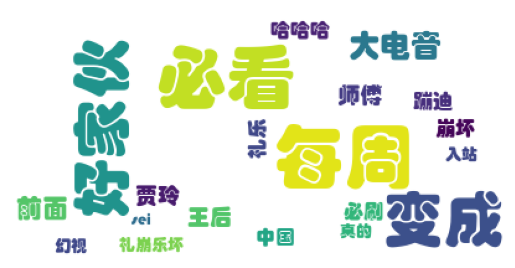

In [4]:
words_df = pd.DataFrame({'segment':segment}) # 新建DataFrame,存储原始的分词结果
words_count=words_df.groupby('segment')['segment'].agg(['count'])
# 当CSV文件的列可能包含分隔符（如逗号）时, 可以使用quoting参数来确保列的完整性
# csv.QUOTE_MINIMAL (0): 只有那些字段中包含特殊字符（如分隔符，引号字符，或者换行符）的时候才会被引号包围。
# csv.QUOTE_ALL (1): 所有的字段都将被引号包围，无论它们的内容。
# csv.QUOTE_NONNUMERIC (2): 所有非数值字段都将被引号包围。
# csv.QUOTE_NONE (3): 没有一个字段会被引号包围，即使字段中包含特殊字符也不会
# stopwords = pd.read_table("./data/stopwords.txt",names=['stopword'],sep='\t',quoting=3)
# words_df = words_df[~words_df.segment.isin(stopwords.stopword)] # 去除停用词表中的词语
# words_df.head(100)
words_count = words_count.reset_index().sort_values(by='count', ascending=False).head(20)
from wordcloud import WordCloud
from matplotlib import pyplot as plt
word_pic=WordCloud(font_path="C:/Windows/Fonts/STHUPO.TTF",background_color="white",max_words=20)
word_freq={x[0]:x[1] for x in words_count.values}
word_pic.fit_words(word_freq)
plt.axis("off")
plt.imshow(word_pic)